<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Hypothesis Testing <a class="tocSkip">

In this notebook we will see:
- the **bootstrap** as a heuristic alternative when no theoretical distribution is available,
- the **hypothesis testing** framework: $H_0$, $H_1$, test statistic, decision rule,
- the two errors a test can make — **Type I** and **Type II** — and the trade-off between them,
- what a **p-value** actually means, and what it does **not** mean.

# Setup

In [1]:
#!pip install  --quiet

In [2]:
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

Running locally, skipping Colab setup.


In [3]:
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Imported matplotlib.
Imported seaborn.
Plotting style set.


# What is Hypothesis Testing

<div style="border-left: 5px solid #4CAF50; background-color: #e8f5e9; padding: 10px; border-radius: 4px; color: inherit;">

A **hypothesis test** checks a claim about the **data-generating** process.

The claim refers to a **property** that may refer to:

1. a **parameter**, such as $\mu$ (_mean_), $\lambda$ (_rate_), $\sigma^2$, or $\beta_1$;
2. a **function of parameters**, such as $\mu_1 - \mu_2$, $\sigma_1^2 / \sigma_2^2$, or $\beta_1 - \beta_2$;
3. a **population feature** not tied to a specific parametric model, such as a median, a quantile, or a rank-based location;
4. the **shape of the distribution**, such as "the data are Normally distributed";
5. the **relationship between variables**, such as independence, association, or equal distributions across groups.

Since we only observe a sample, we compute a **statistic** from the **sample** and ask:

> _Is the observed value plausible if the claim were true?_

</div><br>

**Special case: fitted models** — When we fit a parametric model, the fitted parameters are **estimates** computed from the sample.

> _They are **statistics** in the formal sense, because they are computed from the sample._

$\rightarrow$ They can be used in a hypothesis test, for example $\hat{\lambda}$ for a Poisson rate $\lambda$ or $\hat{\beta}_1$ for a regression slope $\beta_1$.

# A study-case: verifying a claim about an average GC mass

Let us use a practical scenario to build an **intuition** about how Hypothesis Testing works.

Later, we will get more **formal**.

## The data

A research team has studied a sample of **Globular Clusters** (**GCs**) and measured their masses.

Let's load and plot their histogram.
> _PS: We will work in log-scale._
> 

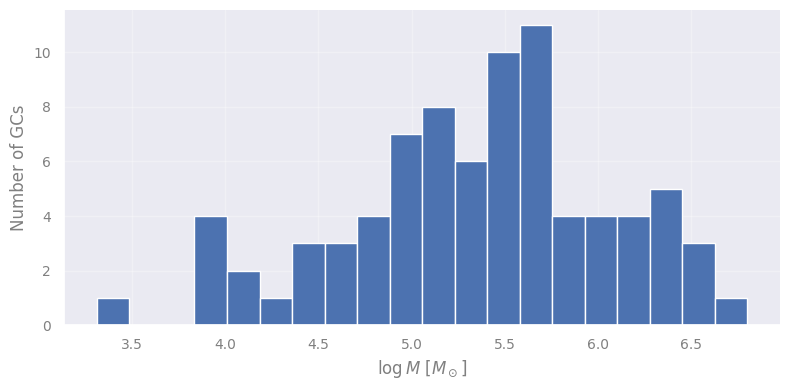

In [21]:
import numpy as np
from scipy import stats

masses = np.genfromtxt("data/GC_masses.csv")
log_masses = np.log10(masses)

plt.hist(log_masses, bins=20)
plt.xlabel(r"$\log M\ [M_\odot]$")
plt.ylabel("Number of GCs")
plt.show()

## The theoretical model

**Globis & Clusterton (2022)** used hydrodynamical galaxy simulations to model the formation of GCs in a galaxy like the Milky Way.

They found that the masses of the synthetic GCs are described by a **model distribution** peaking at $10^{5.5} M_\odot$.

Let's **overplot** the model on the data for a quick comparison.


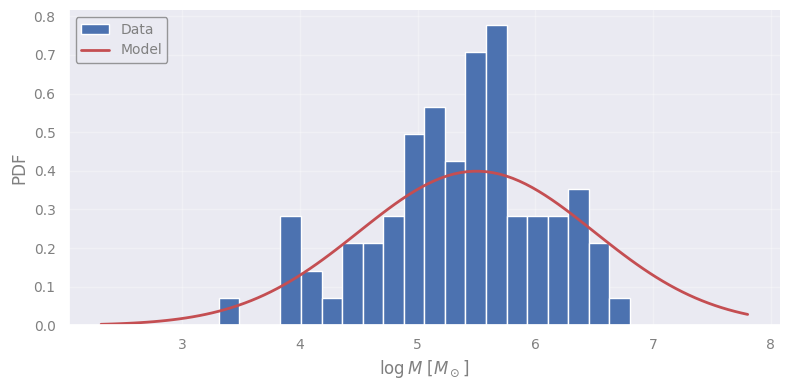

In [23]:
model_mean = 5.5
model_std  = 1.0

logm_for_plot = np.linspace(min(log_masses)-1, max(log_masses)+1, 100)
model_prob_for_plot = stats.norm(model_mean, model_std).pdf(logm_for_plot)

plt.hist(log_masses, bins=20, density=True, label="Data")
plt.plot(logm_for_plot, model_prob_for_plot, "r-", lw=2, label="Model")
plt.xlabel(r"$\log M\ [M_\odot]$")
plt.ylabel("PDF")
plt.legend(loc="upper left")
plt.show()

## The claim

The authors of the model push the following **claim** about the **data-generating** process:

> _GC formation in Milky Way-like galaxies (**data-generating process**) produces a mass distribution that **follows our model** (**claim**)._

This is the **hypothesis** we need to **test**.


## The property

**Q:** What does it mean the statement: "_follows our model_"?

**A:** We need to translate this into a **measurable property**.

We may use <u>any</u> property we can think of — e.g.:
- the **location** of the peak of the model (_as opposed to that of the data_)
- the **value** at the peak (_as opposed to that of the data_)
- the **shape** of the model (_as opposed to that of the data_)
- _etc._

Let's go simple $\rightarrow$ We decide to use the **location** of the peak.

<div style="border-left: 5px solid #4CAF50; background-color: #e8f5e9; padding: 10px; border-radius: 4px; color: inherit;">

In this case, the claim refers to a quantity referring to a **parameter** of a model — case (**1**) in the green box above.

</div>

## The statistic

We now need a **statistic** <u>on the sample</u> to verify the claim.

The statistic shall work as an **estimator** of the **property** we want to measure (_we ignore the real value_).

**Q:** What estimator we could _possibly_ use for the central value?

**A:** Again, many, but we go simple — We will use the **sample mean**:

$$ \bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i \tag{1} $$

<div style="border-left: 5px solid #4CAF50; background-color: #e8f5e9; padding: 10px; border-radius: 4px; color: inherit;">

So, to summarize:

- **data-generating process:** GC formation ir real galaxies.
- **property relevant to the claim:** peak of the distribution.
- **claim:** the observed distribution of GCs is compatible with the model, so it peaks at $10^{5.5} M_\odot$.
- **statistic to probe the claim:** the sample mean $\bar{x}$ of the observed log-masses.

</div>

In [19]:
sample_mean = np.mean(log_masses)

print(f"MODEL:  peak = {model_mean:.2f}")
print(f"SAMPLE: mean = {sample_mean:.2f}")

MODEL:  peak = 5.50
SAMPLE: mean = 5.35


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: does the standard deviation give a sense of how close the mean values are?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

Not exactly. The standard deviation describes the scatter of the data. In itself, it does not say much about the deviation of the sample mean from the model's expectation.

</details>

</div>

In [ ]:
sample_mean = np.mean(log_masses)
sample_std = np.std(log_masses)

print(f"MODEL:  Mean = {model_mean:.2f} | Std = {model_std:.2f}")
print(f"SAMPLE: Mean = {sample_mean:.2f} | Std = {sample_std:.2f}")

## Standard error of the mean

Whether the mean of the sample is close to the mean of the model depends on the sample size. The larger the sample size, the more accurate our estimate of the mean. As we increase the size we would expect the mean to converge to the mean of the model (and that of the underlying population, if the model is correct). 

For normally distributed data the **standard deviation of the mean** scales as:

$$ \Large \sigma_{\bar{x}} = \frac{\sigma}{\sqrt{N}} $$

where $\sigma$ is the population standard deviation and $N$ is the sample size.

In most cases, the standard deviation of the population is unknown. For this reason, we use the same sample to estimate it, calculating the *sample standard deviation*, $s$. The standard deviation of the sample mean is called **standard error on the mean**:

$$ \Large s_{\bar{x}} = \frac{s}{\sqrt{N}} $$

The sample mean is considered to be normally distributed (see *Central Limit Theorem* below), and therefore we can calculate the number of standard errors the theoretical value is away from the sample mean, or the **sigmas**.

In [ ]:
# computing the standard error of the mean, and the difference in terms of sigmas from the model mean
sample_sem = stats.sem(log_masses)
print(f"Standard error of the mean = {sample_sem:.2f}")
print(f"Sigma's of difference      : {(model_mean-sample_mean) / sample_sem:.2f}")

x_plot = np.linspace(sample_mean - 5 * sample_sem, sample_mean + 5 * sample_sem, 100)

# the distribution of the sample mean (using the measured value and the standard error of the mean)
mean_distribution = stats.norm(sample_mean, sample_sem)

# plotting
y_plot = mean_distribution.pdf(x_plot)
plt.figure()
plt.plot(x_plot, y_plot, "k-", lw=2, label=r"$\mathcal{N}$(mean, SEM)")
plt.axvline(sample_mean, ls="-", color="b", label="Sample mean")
plt.axvline(model_mean, ls="--", lw=2, color="r", label="Model mean")
for sigmas in [1, 2, 3]:
    plt.axvspan(sample_mean - sigmas*sample_sem, sample_mean + sigmas*sample_sem, color="b", alpha=0.1)
plt.legend(loc="upper left")
plt.ylim(ymin=0.0)
plt.xlabel(r"$\log M\ [M_\odot]$")
plt.ylabel("PDF of the sample mean")
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: is the means' difference small enough to accept the model?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

Still subjective! But we are closer to quantifying this "subjectiveness"!

</details>

</div>

## When to reject a model...

One might argue that if the theoretical mean is too extreme, either **too low** or **too high** compared to the sample mean, then we should **reject the hypothesis that the model describes the data at hand**. 

We can actually calculate from the sample mean distribution what is the probability of such extreme values.

In [ ]:
x_plot = np.linspace(sample_mean - 5 * sample_sem, sample_mean + 5 * sample_sem, 100)

diff = abs(sample_mean - model_mean)
xx_before = np.linspace(sample_mean - 5 * sample_sem, sample_mean - diff, 100)
xx_after = np.linspace(sample_mean + diff, sample_mean + 5 * sample_sem, 100)

mean_distribution = stats.norm(sample_mean, sample_sem)
y_plot = mean_distribution.pdf(x_plot)

plt.figure()
plt.fill_between(xx_before, mean_distribution.pdf(xx_before), 0, color="r", ec="none", alpha=0.5, label="Area more extreme")
plt.fill_between(xx_after, mean_distribution.pdf(xx_after), 0, color="r", ec="none", alpha=0.5)
plt.plot(x_plot, y_plot, "k-", lw=2, label="N(mean, sem)")
plt.axvline(sample_mean, ls="-", color="b", label="Sample mean")
plt.axvline(model_mean, ls="--", lw=2, color="r", label="Model mean")
plt.legend(loc="upper left")
plt.ylim(ymin=0.0)
plt.xlabel(r"$\log M\ [M_\odot]$")
plt.ylabel("PDF of the sample mean")
plt.show()

The cumulative distribution function is

$$ \Large F(x) = \int\limits_{-\infty}^{x} f(x') dx' $$

The "area more exteme" is 

$$
\begin{aligned}
\Large p   
    &= \Large 1 - \textrm{(area between)} = \\
    &= \Large 1 - \int\limits_{m-d}^{m+d} f(x') dx' = \\
    &= \Large 1 - \left(\int\limits_{-\infty}^{m+d} f(x')dx' - \int\limits_{-\infty}^{m-d} f(x')dx' \right) = \\
    &= \Large 1 - \left[F(m+d) - F(m-d)\right]
\end{aligned}
$$

where $m$ is the sample mean, and $d$ is its absolute distance from the model's mean.

In our case, we have...

In [ ]:
area_more_extreme = 1 - (mean_distribution.cdf(sample_mean+diff) - mean_distribution.cdf(sample_mean-diff))
print(f"Area more extreme, p = {area_more_extreme:.4f}")

Using the correct words is crucial here: This is the **probability of being wrong if we reject the model**! So, the smaller this number, the more safely we can reject the model.

We find a $\sim 7\%$ probability, or **$p$-value** 0.07, of being wrong if we reject this model. *Can we risk it*? It is **our choice** to consider our "threshold" or **significance level**!

If we had decided **before looking at the data** to use a 5% threshold, then our conclusion would be: 

> *we do not reject the model, with a significance level of 5%", or equivalently, we have a 5% probability of being wrong in rejecting the model.*

#### IMPORTANT: we didn't accept the model
The analysis above does not validate the model! The only thing we verified is that **one property**, the mean value of the sample, is not too different than what we would expect from the model. If it was, then we would have reasons to believe that this model is incorrect. For example, if we had found $p=0.0001$ we would **reject the model** given the sample at hand ($0.01\%$ chance of being wrong in doing so).

In Science, we can only disprove theories, never prove them (see Karl Popper's work on philosophy of science). For example, a theory postulates that "all swans are white" - in order to confirm it, one needs to observe all swans in existence, but finding just one swan of different color is enough to disprove it.

> "It doesn't matter how beautiful your theory is, it doesn't matter how smart you are. If it doesn't agree with the experiment, it's wrong." --- Richard Feynmann


#### IMPORTANT: 100-7=93% is not the probablity for the hypothesis (or model) to be correct
There are infinite other models under which the $p$-value would be above our threshold, for example, $N(5.5, 0.101)$, $N(5.51, 0.1)$, ...

> "Whenever a theory appears to you as the only possible one, take this as a sign that you have neither understood the theory nor the problem which it was intended to solve." --- Karl Popper


### Choosing the significance level

There is no rule on what the significance level should be. Just that it should be decided before looking at the data. This is important in order to avoid **biasing our conclusions by relaxing our criteria for models that we like, or making it harder for models that we don't like**, a typical behaviour often displayed by humans without realizing it.

In Astronomy, $2 + 2 \simeq 5$, so we often use 0.5, 1 or 5%. In Nuclear Physics and precision experiments often $10^{-7}$ or $10^{-10}$ are used!

Since the $p$-value is connected to the number of sigmas in difference, often we refer to *sigmas* instead of a significance level. It is shorter to say and easier to visualize in plots with error bars and distributions. For example:

| Sigmas | Probability (inside) | Probability (outside) |
| --- | --- | --- |
|  1 | 0.68 | 0.32 |
|  2 | 0.954 | 0.046 |
|  3 | 0.9973 | 0.0027 |
|  5 | 0.9999994 | 0.0000006 |
|  8 | 0.9999999999999987 | 0.0000000000000013


> "Creationists make it sound as though a 'theory' is something you dreamt up after being drunk all night." --- Isaac Asimov

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: what does it mean to have a $p=1.52{\times}10^{-23}$ (10-sigma) particle detection? Is it good that the $p$-value is very small?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>  

Never judge before considering what is the Null Hypothesis: the hypothesis which is considered to be true in order to calculate the expected distribution of the statistic!

Previously, we checked a specific model, and therefore our null hypothesis was that the data agree with it (at least their mean).

In particle detectors, the null hypothesis is usually "the signal was noise", which tests whether the data came about randomly. Rejecting that a signal is noise with significance level of 0.0000000000000000000015% is not bad at all!

</details>

</div>

## Recap: the steps of *Hypothesis testing*

> **Step 1**: We define the **null hypothesis** or the statement that we will test (a model or random outcome).

> **Step 2**: We decide on a **significance level** that we are comfortable with - or the "probability for being wrong in rejecting the null hypothesis".

> **Step 3**: The **statistic** - a quantity that is computed on our *sample* assuming the *hypothesis is true*.

> **Step 4**: We compute the **$p$-value** OR **critical value**: the actual value(s) of the statistic based on which we will reject the hypothesis or not.

> **Step 5**: The decision!


### Step 1. We define the null hypothesis

> $H_0$: the mean value of the decimal logarithm of the masses of Milky Way GCs is consistent with the model.

### Step 2. We decide on a significance level

This is the "probability of being wrong" in rejecting the hypothesis using the data at hand.

> Let's take a significance level of $5\%$, i.e. $a = 0.05$

### Step 3. The statistic, $Z$-score

#### Note: we should use the population standard deviation if we know it (as opposed to the sample standard deviation), see "Standard error of the mean" above.

In order to decide whether the sample mean is consistent with the model's prediction, we must compute the **distribution of the sample mean given that the model is correct.**

For $N$ observations $x_i$ the sample mean, $\bar{x}$ is

$$ \Large \bar{x} = \frac{1}{N} \sum\limits_{i=1}^{N} x_i$$

For normally distributed observations, $x_i \sim \mathcal{N}(\mu, \sigma)$, it is known that the sample mean is also normally distributed with mean equal to the population mean ($\mu$) and standard deviation equal to the population standard deviation ($\sigma$) devided by the square root of the size of the sample ($N$):

$$ \Large \bar{x} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{N}\right)$$

...called *standard deviation of the mean*:

$$ \Large \sigma_{\bar{x}} = \frac{\sigma}{\sqrt{N}}$$

Therefore the probability density function (PDF) of the sample mean is:

$$ \Large f(\bar{x}) = \frac{1}{\sqrt{2\pi \ \sigma_{\bar{x}}^2}} \exp\left[-\frac{\left(\bar{x} - \mu\right)^2}{2 \ \sigma_{\bar{x}}^2}\right]$$

Because of the ability to shift and scale the normal distribution, the quantity

$$ \Large Z = \frac{\bar{x} - \mu}{\sigma_{\bar{x}}} $$

follows the standard normal distribution (i.e. mean value $0$ and standard deviation $1$):

$$ \Large f(Z) = \frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2}Z^2}$$

Therefore, by just computing $Z$ from our sample, $z$, we can easily use tables for the normal distribution or code to quickly compute the probability at which $Z$ is below or above a specific value.

We call this value "$Z$ *statistic*" or "$Z$ *score*" and it is good choice the quantity we use to test the hypothesis is normally distributed.

### Step 4. We compute the $p$-value and critical value(s) for the statistic

<img src="images/critical_pvalue.png" width=600 style="display:block; margin-left:auto; margin-right:auto;">

<p style="text-align: center; font-size: 0.9em; color: gray;">Figure 1. Critical value and corresponding $p$-value for a two-tailed test, meaning that we want to quantify how extreme the difference is, regardless of whether the actual sample statistic is greater or lower than the theory.
</p>


We need to convert the null hypothesis statement "consistent with..." to a quantitative statement. In this example, we can consider that the sample mean is inconsistent with the model prediction if its significantly lower or higher than the significant level (this is a *two-tail test*).

Therefore, the Type I error is equal to probability that the $Z$ score deviates more than the absolute deviation of the score for the sample at hand**:

$$ \Large p = P(Z > |z|) + P(Z < -|z|) $$

Using the symmetry of normal distribution's PDF and the fact that $P({\rm A}) + P({\rm not\ A}) = 1$, we arrive at

$$ \Large p = \cdots = 2 \left(1 - P\left(Z < |z|\right)\right) = \cdots = 2 P(Z < -|z|)$$

or simply,

$$ \Large p = 2 \Phi(-|z|) $$

where $\Phi(z)$ is the CDF of the standard normal distirbution.

If we find $p < a$ (which we selected early on at step 2 above) then we reject the null hypothesis.

Alternatively, we can set **critical** values of the $Z$ score that correspond to the significance level of choice. As rejection should occur either for higher or lower values (two-tailed test), we find two critical values corresponding to $a/2$ probability:

$$ \Large Z_{\rm crit,1} = \Phi^{-1}\left(\frac{a}{2}\right) = -1.96 $$

$$ \Large Z_{\rm crit,2} = \Phi^{-1}\left(1 - \frac{a}{2}\right) = +1.96 $$

Because of the symmetry of the normal distribution we could also compute a critical value for the absolute $Z$ score:

$$ \Large |Z|_{\rm crit} = 1.96 $$

This is equivalent to asking *how many **sigmas** away from the model prediction can the measured value be in order to reject the null hypothesis?* Astronomers are used to this $\sigma$ term: "we reject the hypothesis at a $2\sigma$ significance level!"

### Step 5. Decision

The decision can now be formulated in words based on the calculated $p$-value (or critical value), the significance level, and the null hypothesis.

# Diagnostic Plots — Does the Distribution Fit?

Estimating $\hat{\boldsymbol{\theta}}$ is "easy" $\rightarrow$ The hard question is whether the distribution you assumed is the **right one**.

Two staple diagnostics:

- For discrete data, plot the **empirical pmf** (relative frequencies) against the **theoretical pmf** with the fitted parameters.<br>
    _That is what we did just above._

- For continuous data, the **Q-Q plot** compares sample quantiles to the quantiles of the assumed distribution.<br>
    _Points on the diagonal mean the fit is good; systematic curvature reveals where the model fails._

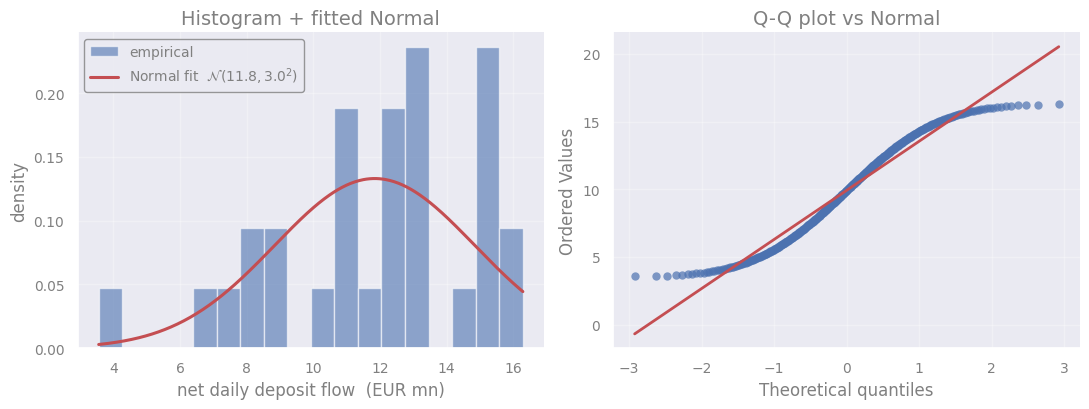

In [25]:
# ── Simulate net deposit flow (in EUR millions) — Normal-ish but with a small skew ──
n = 30
rng = np.random.default_rng(seed=42)
x = rng.normal(loc=12.0, scale=4.0, size=n)
x += 0.6 * rng.standard_t(df=4, size=n)   # mild fat tail

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Histogram + Normal fit
ax = axes[0]
ax.hist(x, bins=18, density=True, alpha=0.6,
        color="C0", edgecolor="white", label="empirical")
mu_hat, sigma_hat = x.mean(), x.std(ddof=0)
x = np.linspace(x.min(), x.max(), 400)
ax.plot(x, stats.norm.pdf(x, mu_hat, sigma_hat), color="C3", lw=2.2,
        label=fr"Normal fit  $\mathcal{{N}}({mu_hat:.1f}, {sigma_hat:.1f}^2)$")
ax.set_xlabel("net daily deposit flow  (EUR mn)")
ax.set_ylabel("density")
ax.set_title("Histogram + fitted Normal")
ax.legend()

# Q-Q plot
ax = axes[1]
stats.probplot(x, dist="norm", plot=ax)
ax.set_title("Q-Q plot vs Normal")
for child in ax.get_lines():
    if child.get_marker() == "o":
        child.set_markerfacecolor("C0")
        child.set_markeredgecolor("none")
        child.set_alpha(0.7)
    else:
        child.set_color("C3")

plt.show()

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

Light deviations at the extremes of the Q-Q plot are common and **do not** invalidate the Normal fit by themselves.

The questions to ask are:

- Are the deviations **systematic** across many days, or driven by 1–2 points?
- Are the tails **heavier** or **lighter** than the model predicts? (Heavier tails → underestimated risk.)

$\rightarrow$ **Hypothesis testing** allows to **quantify** what we may infer from the plots.

</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

## Exercise [10 min]

**Objective:** Plot the empirical pmf of a Poisson sample and compare its centre with the **true value** $\lambda_0$.

**Setting:** A card-issuer monitoring desk records the number of **fraud alerts per hour**.

The true hourly rate is $\lambda_0 = 3.6$. We collect $n = 14 \times 24 = 336$ hours of data.

_In particular, you must:_

1. **Generate** the dataset using the cell provided right below — It uses `rng.poisson(true_lambda, size=n)` to draw the counts.
2. **Plot** the empirical pmf of the counts (use `plt.bar`).
3. **Mark** the expected value $\lambda_0 = 3.6$ on the plot as a single vertical line (use `plt.axvline`).
4. **Look at the plot:** is the empirical mass concentrated around $\lambda$, as theory predicts?

</div>

In [26]:
# ── Given data — do not change the seed ───────────────────────────────────
lambda_0 = 3.6  # true lambda
n = 14 * 24

rng = np.random.default_rng(seed=42)
x = rng.poisson(lambda_0, size=n)

In [271]:
# Student: Write your code here. Add blocks as you deem fit.

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[Solution below]</b>

</div>


In [36]:
print( (x == 0).sum()/n )

print( (x == 0).mean() )

0.02976190476190476
0.02976190476190476


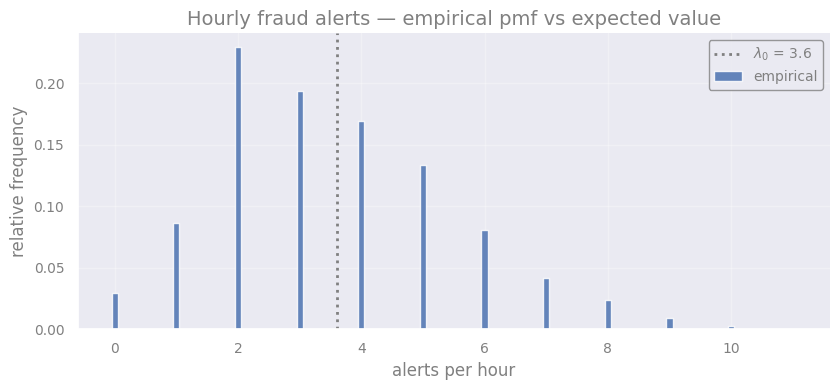

In [27]:
# Empirical pmf with the expected value lambda marked
k_grid = np.arange(0, x.max() + 2)
emp    = np.array([(x == k).mean() for k in k_grid])

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(k_grid, emp, color="C0", alpha=0.85, edgecolor="white", label="empirical", width=0.1)
ax.axvline(lambda_0, color="gray", lw=2, ls=":",
           label=fr"$\lambda_0$ = {lambda_0}")
ax.set_xlabel("alerts per hour")
ax.set_ylabel("relative frequency")
ax.set_title("Hourly fraud alerts — empirical pmf vs expected value")
ax.legend()
plt.show()

**Comment:**

The empirical bars cluster around the dashed line at $\lambda_{0} = 3.6$ — the peak sits at $k = 2{-}3$ and the bulk of the mass spans 1 to 5. The right tail thins out gradually past the line, the typical right-skewed Poisson signature.

The sample's centre lands close to $\lambda_{0}$ — consistent with theory.


<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[End of solution]</b>

</div>


# The Hypothesis Testing Framework

Once we believe data follows a known distribution, we can ask **decision questions** of the form:

> _Is the observed data compatible with a working claim about $\theta$, or unusual enough that we should reject it?_

Hypothesis testing is the disciplined way to answer that question with a **probability of being wrong** attached to it.

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

**Formal framework**

We never prove the claim true, but assess when the data deviates from it strongly **enough to reject it** $\dots$<br>

$\dots$ while keeping the **probability of falsely rejecting** bounded by a level **$\alpha$** chosen up front.

</div>
<br>

The _whole process_ is outlined in the following image, and described in the remainder:

<table><tr>
    <td width=900>
        <img src="images/fig_hypothesis_flow.png" width="900">
    </td>
</tr></table>

<table><tr>
    <td width=900>
        <center>
            Figure 2. The four-step recipe of any hypothesis test — state, choose a test, compute, decide.
        </center>
    </td>
</tr></table>

## Null and Alternative Hypothesis

Any test starts with two mutually-exclusive statements about the world.

- The **null hypothesis** $H_{0}$ encodes the *status quo* — the claim we are willing to keep if the data does not strongly contradict it.
- The **alternative hypothesis** $H_{1}$ encodes the *challenger* — the claim we accept only if the data points clearly away from $H_{0}$.

The test is **conservative**: $H_{0}$ is innocent until proven guilty.



One more sub-category — **One/Two-sided** tests:

- Two-sided $H_{1}$ asks *is the parameter different?*
- One-sided $H_{1}$ asks *is the parameter larger / smaller?*

<div style="border-left: 4px solid #9C27B0; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; background-color: #f6f2fa; margin-top: 1em;">

<strong>Business Lens — Picking $H_0$ in banking.</strong>

$\rightarrow$ Pick the null so that <em>incorrectly rejecting it</em> is the **more expensive** mistake.

_Examples:_

- If you are evaluating a change to a fraud rule:<br>
  > $H_0$ should be $\rightarrow$ "the new rule does not differ from the baseline"
    
  _(You do not want to roll out a fake improvement)_

- If you are evaluating an Service Level Agreement (SLA) breach:<br>
    
    > $H_0$ should be $\rightarrow$ "the SLA is met"
    
    _(You do not want to falsely accuse the vendor)_

</div>

## Test Statistics and Rejection Regions

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

A **test statistic** is a function of the sample — let's call it $T$ — chosen so that:
- under $H_{0}$, the distribution of $T$ is **known**;
- under $H_{1}$, $T$ tends to take **larger** (in absolute value) values.

Given a **significance level** $\alpha$ (commonly 0.05 or 0.01), the **rejection region** is the set of $T$ values that are unlikely enough under $H_{0}$ that we would rather reject:

$$ R_{\alpha} = \{\, t : P(\,|T| \geq |t|\, \mid H_{0}) \leq \alpha \,\}. \tag{8}$$

</div>

## Example: Silence at the fraud desk

Under normal operating conditions the fraud-monitoring system raises $\lambda_{0} = 2$ alerts per hour — one every **30 minutes** on average.

During a market stress event the desk observes a silence of $x_{\rm obs} = 1.2$ hours: no alert fires.

**Q:** Is this silence just a run of normal luck — or is the alert rate genuinely lower than usual?

**A:** _Let's follow the recipe of Figure 2 $\dots$_

<br>

In [40]:
lam0  = 2.0   # baseline alert rate (alerts / hour)
x_obs = 1.2   # observed silence (hours)

### Step 1.A — State the hypotheses

- $H_{0}:\; \lambda = \lambda_{0}$ — the alert rate matches the baseline.
- $H_{1}:\; \lambda < \lambda_{0}$ — one-sided alternative: the system is **quieter than normal**.

### Step 1.B — Choose the significance level

We fix $\alpha = 0.05$ up front.

What this implies? $\rightarrow$ Under $H_{0}$ we accept a 5% long-run rate of falsely flagging a normal silence as anomalous.

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

Are you ok with 5%?

Or would you prefer a more stringent significance level?

Write down your choice in the cell below.

Be warned: **you cannot change this later.**

</div>

In [41]:
alpha = 0.05

### Step 2.A — Pick a test statistic

We take the simplest possible choice: the **observed gap itself**,

$$ T \;=\; X, $$

where $X$ is the duration (in hours) from the last alert to now.

### Step 2.B — Assume the statistic PDF

We **assume** the gap between alerts follows an exponential distribution — Under $H_{0}$ its rate is $\lambda_{0}$, so its **PDF** is:

$$ p(x \mid \lambda_{0}) \;=\; \lambda_{0} e^{-\lambda_{0} x}, \quad x \geq 0. \tag{9} $$

### Step 3 — Compute the p-value

A **long** silence is evidence against $H_{0}$ $\rightarrow$ p-value is the right-tail probability under the null:

$$ p_{\rm value} \;=\; P(X \geq x_{\rm obs} \mid \lambda_{0}) \;=\; \int_{x_{\rm obs}}^{\infty} \lambda_{0}\, e^{-\lambda_{0} x}\, dx \;=\; e^{-\lambda_{0}\, x_{\rm obs}}. \tag{10}$$

Graphically, the p-value is the area under the pdf to the **right** of $x_{\rm obs}$.

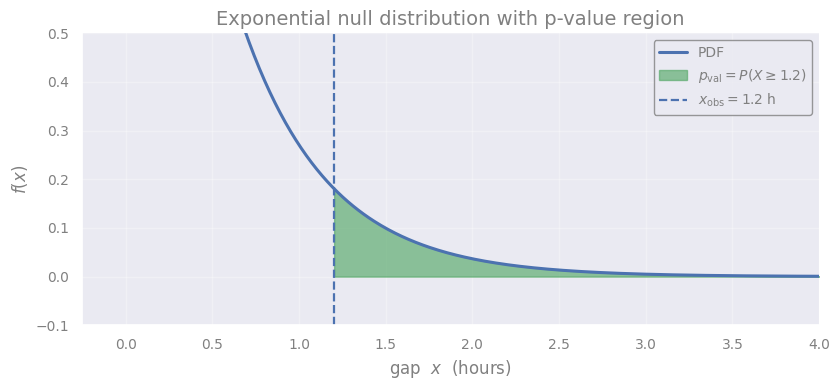

In [47]:
# ── Exponential null distribution and p-value region ─────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x   = np.linspace(0, 5, 500)
pdf = stats.expon.pdf(x, scale=1 / lam0)

fig, ax = plt.subplots(figsize=(8.5, 4))

ax.plot(x, pdf, color="C0", lw=2.2,
        label=r"PDF")

mask = x >= x_obs
ax.fill_between(x[mask], pdf[mask], alpha=0.65, color="C2",
                label=fr"$p_{{\rm val}} = P(X \geq {x_obs:.1f})$")

ax.axvline(x_obs, color="C0", ls="--", lw=1.6,
           label=fr"$x_{{\rm obs}} = {x_obs:.1f}$ h")

# # rejection region (red)
# mask_a = x >= x_alpha
# ax.fill_between(x[mask_a], pdf[mask_a], alpha=0.45, color="firebrick",
#                 label=fr"$\alpha = {alpha}$ region  ($x_\alpha = {x_alpha:.2f}$ h)")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.set_xlabel("gap  $x$  (hours)")
ax.set_ylabel(r"$f(x)$")
ax.set_title("Exponential null distribution with p-value region")
ax.set_xlim([None, 4])
ax.set_ylim([None, 0.5])
ax.legend()
plt.show()

We can compute the p-value directly from Equation 10:

In [45]:
import numpy as np

p_val = np.exp(-lam0 * x_obs)  # closed form

print(f"p-value: {p_val:.4f}")

p-value: 0.0907


### Step 4 — Apply decision

Reject $H_{0}$ if $p_{\rm val} < \alpha$.

This is the **exact exponential test** — the simplest possible hypothesis test on a continuous distribution, with the reference distribution read straight off the pdf.

In [46]:
if p_val < alpha:
    print(f"p_val ({p_val:.4f}) < alpha ({alpha}) -> reject H0")
else:
    print(f"p_val ({p_val:.4f}) >= alpha ({alpha}) -> do NOT reject H0")

p_val (0.0907) >= alpha (0.05) -> do NOT reject H0


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

**REMEMBER:** Failing to reject is not the same as proving $H_0$ true!

</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

## Exercise [15 min]

**Objective:** Apply the four-step recipe to a simple test whose statistic has a **Gaussian** PDF under $H_{0}$.

**Setting:** A monitoring system reports one number per day. Under normal operation the number is Gaussian with known mean $\mu_{0} = 50$ and known standard deviation $\sigma = 10$.

Today we observe $x_{\rm obs} = 70$. Is this unusually high?

_In particular, you must:_

1. **State** $H_{0}: \mu = \mu_{0}$ and $H_{1}: \mu > \mu_{0}$ (one-sided, right tail).
2. **Pick** the test statistic $T = X$ — the observation itself. Under $H_{0}$ its PDF is $p(x \mid \mu_{0}, \sigma)$, a Gaussian with mean $\mu_{0}$ and standard deviation $\sigma$.
3. **Compute** the p-value $P(X \geq x_{\rm obs} \mid H_{0})$ using `scipy.stats.norm.sf`.
4. **Decide** at $\alpha = 0.05$ and state the conclusion in plain language.

</div>

In [209]:
# ── Given values — do not change them ─────────────────────────────────────
mu0   = 50.0
sigma = 10.0
x_obs = 70.0
alpha = 0.05

In [210]:
# Student: Write your code here. Add blocks as you deem fit.

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[Solution below]</b>

</div>

In [211]:
# ── Solution ──────────────────────────────────────────────────────────────
from scipy import stats

p_val = stats.norm.sf(x_obs, loc=mu0, scale=sigma)
print(f"p-value = {p_val:.4f}")

if p_val < alpha:
    print(f"p_val ({p_val:.4f}) < alpha ({alpha}) -> reject H0")
else:
    print(f"p_val ({p_val:.4f}) >= alpha ({alpha}) -> do NOT reject H0")

p-value = 0.0228
p_val (0.0228) < alpha (0.05) -> reject H0


**Comment:**

The observed value sits 2 standard deviations above the mean — well into the right tail.

The p-value is about 0.023, below $\alpha = 0.05$, so we **reject** $H_{0}$ $\rightarrow$ The observation is statistically inconsistent with normal operation.

# Type I and Type II Errors

Every test can be wrong in 2 distinct ways.

- **Type I error.** Reject $H_{0}$ when it is in fact true.<br>
  _The probability of this happening is exactly $\alpha$, the significance level we chose._
  
- **Type II error.** Fail to reject $H_{0}$ when it is in fact false.<br>
  _The probability of this happening is called $\beta$ and depends on the **true** value of the parameter under $H_{1}$._

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

The complement of $\beta$ is the **power** of the test:

$$ \text{Power} = 1 - \beta = P(\text{reject } H_{0} \mid H_{1}\text{ true}). \tag{11}$$

</dev>

<table><tr>
    <td width=900>
        <img src="images/fig_type_errors.png" width="900">
    </td>
</tr></table>

<table><tr>
    <td width=900>
        <center>
            <br>
            Figure 3. The two errors share one cut-off. Lowering $\alpha$ shrinks the red zone but enlarges the violet zone. Only a larger sample shrinks both at once.
        </center>
    </td>
</tr></table>

Useful rules of thumb for sample size:

- A larger $n$ shrinks the standard error of $\hat{\theta}$ $\rightarrow$ sharpens both distributions $\rightarrow$ **increases power** at any fixed $\alpha$.
- A smaller effect size (the gap between the true parameter and the null value) requires a larger $n$ to detect at a given power.
- Power calculations should happen **before** the test, not after.

## How does power change with the true parameter value?

**Following on the example above $\dots$**

- The Type-I rate is fixed at $\alpha$ by construction.

- The Type-II rate $\beta$ — and therefore the **power** $1 - \beta$ — depend on **where the unknown true rate $\lambda$ actually lies** relative to $\lambda_{0}$.

Below we fix $\alpha = 0.05$ and trace the power as a function of the unknown true $\lambda$.

The **critical threshold** is the gap length beyond which we reject $H_{0}$:

$$ x_{\alpha} \;=\; \frac{-\ln \alpha}{\lambda_{0}}. $$

The **power** at any unknown true $\lambda$ is then:

$$ \text{Power}(\lambda) \;=\; P(X \geq x_{\alpha} \mid \lambda) \;=\; e^{-\lambda\, x_{\alpha}}. $$

When $\lambda = \lambda_{0}$, the power equals $\alpha$ — by construction we reject $H_{0}$ only 5% of the time.

As $\lambda$ falls below $\lambda_{0}$ (silences become typically longer), the power climbs toward $1$ $\rightarrow$ the true slowdown becomes harder to miss.

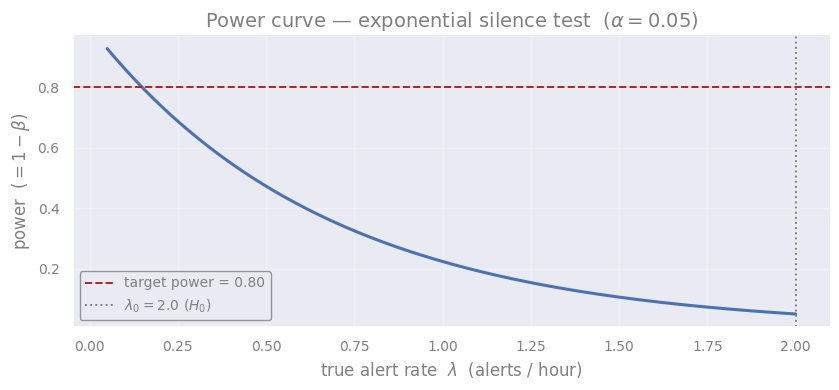

In [49]:
# ── Power curve for the exponential silence test ──────────────────────────
lam0    = 2.0
alpha   = 0.05

x_alpha = -np.log(alpha) / lam0                 # critical threshold (hours)

lam_grid = np.linspace(0.05, 2.0, 300)
power    = np.exp(-lam_grid * x_alpha)          # Power(lambda) = e^{-lambda * x_alpha}

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(lam_grid, power, color="C0", lw=2.2)
ax.axhline(0.8,  color="firebrick", ls="--", lw=1.4, label="target power = 0.80")
ax.axvline(lam0, color="gray",      ls=":",  lw=1.4, label=fr"$\lambda_0 = {lam0}~(H_{0})$")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.set_xlabel(r"true alert rate  $\lambda$  (alerts / hour)")
ax.set_ylabel(r"power  $(= 1 - \beta)$")
ax.set_title(fr"Power curve — exponential silence test  ($\alpha = {alpha}$)")
ax.legend()
plt.show()

# Bootstrap Hypothesis Tests

Every test seen so far rests on a **theoretical** reference PDF for the test statistic under $H_{0}$.<br>

That ingredient is not always available $\rightarrow$ 2 situations where the theoretical PDF is **missing**:

- The statistic of interest is **non-standard** — _e.g., a median, a quantile, a trimmed mean, a Sharpe ratio, a custom risk indicator._<br>

- The data clearly violates the **assumptions** of the standard test — _heavy tails, strong asymmetry, very small $n$, or dependence_ — so the theoretical reference PDF is not trustworthy _even_ when it exists.

The **bootstrap** sidesteps the problem by building the reference distribution **directly from the data**.

> _It is a **heuristic** procedure: it treats the empirical sample as a proxy for the population and resamples from it._


<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

**Bootstrap one-sample test** for a generic statistic $\hat{T}$ with null $H_{0}: T = T_{0}$:

1. Compute $\hat{T}_{\rm obs}$ on the original sample $\{x_{1}, \dots, x_{n}\}$.

2. **Shift the sample** so that the null holds — produce $\{x_{i}^{\prime}\}$ such that the statistic evaluated on it equals $T_{0}$.<br>
_For tests on a centre, this is $x_{i}^{\prime} = x_{i} - \hat{T}_{\rm obs} + T_{0}$._

4. Draw $B$ samples of size $n$ with replacement from $\{x_{i}^{\prime}\}$; on each, compute $\hat{T}_{b}^{*}$.

5. The collection $\{\hat{T}_{1}^{*}, \dots, \hat{T}_{B}^{*}\}$ is the bootstrap reference distribution **under $H_{0}$**.

6. The two-sided p-value is the empirical tail mass beyond the observed deviation:

$$ p_{\rm value} \;\approx\; \frac{1}{B}\sum_{b=1}^{B} \mathbf{1}\!\left[\,\bigl|\hat{T}_{b}^{*} - T_{0}\bigr| \;\geq\; \bigl|\hat{T}_{\rm obs} - T_{0}\bigr|\,\right]. \tag{12}$$

</div>

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

The **price**: we lose the clean theoretical guarantee — bootstrap works because of asymptotic results and accumulated empirical evidence.

The **reward**: it works for almost any statistic, on almost any data, with the same handful of lines of code.

</div>

## Example: median monthly transactions per active retail customer

Suppose we know the **median** monthly transaction count for active retail customers is: $m_{0} = 18$.

The product team pulls a fresh sample of 60 customers and asks whether the true median has changed.

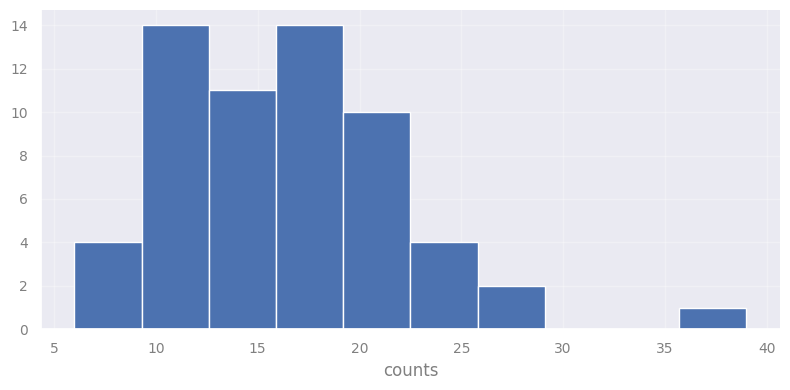

sample median  = 16.00
benchmark m0   = 18
observed gap   = -2.00


In [54]:
# ── Sample of 60 active retail customers — slightly skewed counts ─────────
n = 60

rng = np.random.default_rng(seed=42)
x = rng.lognormal(mean=np.log(15), sigma=0.45, size=n).round().astype(int)  # sample some data
'''
The lognormal is the Generative Process of the observed data for this example.
It may or may not have a true median compatible m_0, we will check exactly this.
''';

plt.hist(x, bins=10)
plt.xlabel('x')
plt.xlabel('counts')
plt.show()

m0 = 18
m_obs = float(np.median(x))

print(f"sample median  = {m_obs:.2f}")
print(f"benchmark m0   = {m0}")
print(f"observed gap   = {m_obs - m0:+.2f}")

The sampling distribution of the median has no clean closed form for $n = 60$, and the data is mildly skewed.<br>
$\rightarrow$ _We hit both of the 2 conditions that makes bootstrapping shine!_

Let's derive 10,000 **bootstrapped samples**, then apply Equation 12 to get the **p-value**.

In [67]:
# ── Bootstrap null distribution of the median ─────────────────────────────
B = 10_000  # Run on 10,000 bootstrapped samples
x_shifted = x - m_obs + m0          # enforce H0 on the resampling pool

boot_idx = rng.integers(0, n, size=(B, n))
boot_samples = x_shifted[boot_idx]
boot_T = np.median(boot_samples, axis=1)

We can also visualize our **empirical PDF for the median**.

This is simply the **histogram** of the 10,000 medians measured on the 10,000 bootstrapped samples!

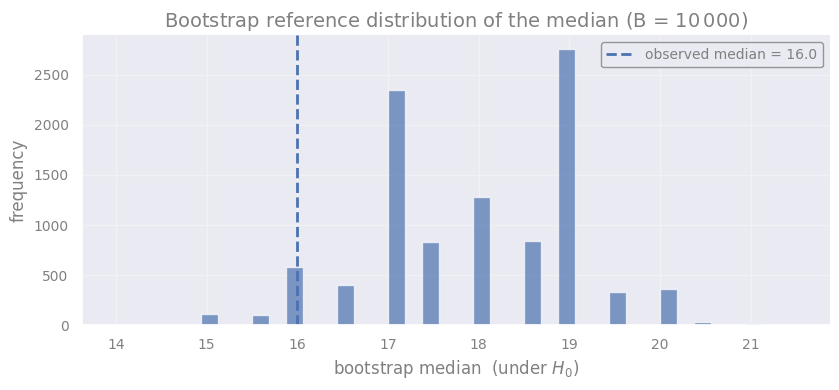

In [66]:
# Visualise the bootstrap reference distribution
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.hist(boot_T, bins=40, color="C0", alpha=0.7, edgecolor="white")
ax.axvline(m_obs, color="C0", lw=2, ls='--', label=f"observed median = {m_obs:.1f}")
# ax.axvline(m0, color="gray", lw=1.4, ls=":", label=fr"$m_0 = {m0}$")
ax.set_xlabel("bootstrap median  (under $H_0$)")
ax.set_ylabel("frequency")
ax.set_title(r"Bootstrap reference distribution of the median (B = 10$\,$000)")
ax.legend()
plt.show()

In [70]:
# Two-sided bootstrap p-value
p_boot = np.mean(np.abs(boot_T - m0) >= abs(m_obs - m0))
print(f"bootstrap p-value (two-sided) = {p_boot:.4f}")

bootstrap p-value (two-sided) = 0.1217


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

The reference PDF was **built from the data itself**.

<u>Whatever</u> the shape of the underlying population, the bootstrap approximates the PDF of the statistic <em>as if</em> it were drawn from that population.

</div>


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

**Curiosity**

For a difference between two groups, the natural counterpart is a <strong>permutation test</strong>: pool the two samples, shuffle the labels, recompute the statistic of interest, repeat $B$ times. The shuffle enforces the null "there is no difference between groups". A two-sample bootstrap variant resamples each group separately and tracks the difference of statistics across the resamples.

</div>


## Caveats — the bootstrap is not magic.

It **inherits the limits of the sample** $\rightarrow$ A small or biased sample produces a small or biased reference distribution.

- It is **unsuitable** for statistics dominated by the **extremes** (_maximum, minimum_), where resampling cannot create new tail behaviour.
  
- It assumes **independent** observations. Time-series and clustered data require block or stratified bootstrap variants.

- The number of resamples $B$ controls the **resolution** of the p-value $\leftarrow$ $B = 10\,000$ resolves p-values down to about $10^{-4}$.

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

## Exercise [40 min]

**Objective:** Run a bootstrap hypothesis test on the **mean** of a heavy-tailed distribution.

**Setting:** A retail bank tracks **monthly fee revenue per branch** as a performance metric. The business plan sets an internal baseline of $\mu_{0} = 60$ (EUR thousand) per branch.

We have one month of data covering **180 branches** and want to test whether the true mean is **above** the baseline.

_In particular, you must:_

1. **Generate** the dataset using the cell provided right below — do **not** change the seed.
2. **Compute** the observed sample mean $\bar{x}$.
3. **State** $H_{0}$ and $H_{1}$, choose a **one-sided** alternative ($H_{1}: \mu > \mu_{0}$).
4. **Build** the bootstrap reference distribution of the mean under $H_{0}$ with $B = 10\,000$ resamples. Use the shift $x_{i}^{\prime} = x_{i} - \bar{x} + \mu_{0}$ to enforce the null on the resampling pool.
5. **Compute** the one-sided bootstrap p-value.
6. **Plot** the bootstrap null distribution with $\bar{x}$ and $\mu_{0}$ marked.
7. **Decide** at $\alpha = 0.05$ and report the conclusion in plain language.

</div>

In [75]:
# ── Given data — do not change the seed ───────────────────────────────────
n = 180

exercise_rng = np.random.default_rng(seed=2604_4003)
x = exercise_rng.lognormal(mean=np.log(60), sigma=0.55, size=n)

print(f"n branches = {n}")
print(f"sample mean   = {x.mean():.1f}  (EUR k)")
# print(f"sample median = {np.median(x):.1f}  (EUR k)")

n branches = 180
sample mean   = 70.3  (EUR k)


In [74]:
x.shape

(180,)

In [198]:
# Student: Write your code here. Add blocks as you deem fit.

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[Solution below]</b>

</div>


In [199]:
# ── Solution ──────────────────────────────────────────────────────────────
# H0: mu = 60     H1: mu > 60     (one-sided, right tail)

mu0    = 60.0
x_bar  = float(x.mean())

print(f"observed sample mean = {x_bar:.2f}  (EUR k)")
print(f"baseline mu0         = {mu0:.2f}")
print(f"observed gap         = {x_bar - mu0:+.2f}")

observed sample mean = 70.26  (EUR k)
baseline mu0         = 60.00
observed gap         = +10.26


In [200]:
# ── Bootstrap null distribution of the sample mean ────────────────────────
B = 10_000
shifted = x - x_bar + mu0     # enforce H0 on the resampling pool

boot_idx     = exercise_rng.integers(0, n, size=(B, n))
boot_samples = shifted[boot_idx]
boot_T       = boot_samples.mean(axis=1)

p_boot = np.mean(boot_T >= x_bar)            # one-sided, right tail
print(f"bootstrap p-value (one-sided) = {p_boot:.4f}")

bootstrap p-value (one-sided) = 0.0026


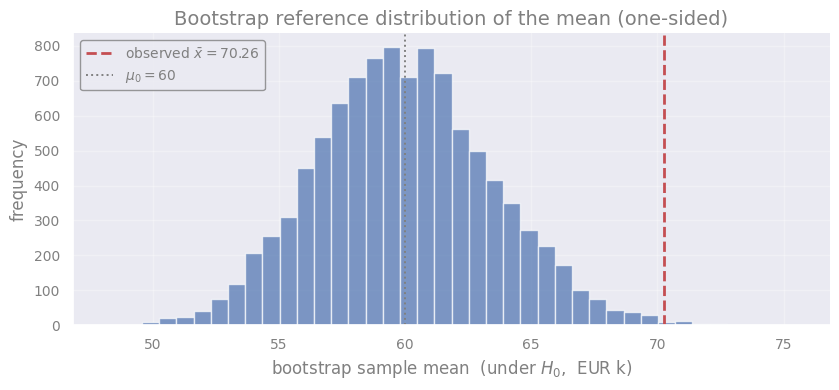

In [202]:
# Visualise the bootstrap reference distribution
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.hist(boot_T, bins=40, color="C0", alpha=0.7, edgecolor="white")

# shade the right-tail rejection region (boot_T >= x_bar)
counts, edges = np.histogram(boot_T, bins=40)
mask = edges[:-1] >= x_bar

ax.axvline(x_bar, color="C3", lw=2, ls='--', label=fr"observed $\bar x = {x_bar:.2f}$")
ax.axvline(mu0,   color="gray", lw=1.4, ls=":", label=fr"$\mu_0 = {mu0:.0f}$")
ax.set_xlabel(r"bootstrap sample mean  (under $H_0$,  EUR k)")
ax.set_ylabel("frequency")
ax.set_title("Bootstrap reference distribution of the mean (one-sided)")
ax.legend()
plt.show()

**Comment:**

The observed mean is well above the baseline of 60, and the one-sided bootstrap p-value falls below 0.05 — the data **rejects** $H_{0}$ at the 5% level. We can claim the true mean fee revenue per branch is statistically higher than the baseline.

Two things to notice:

- The reference distribution is **roughly symmetric** around $\mu_{0}$ — the Central Limit Theorem kicks in for the mean even with a heavy-tailed underlying distribution.
- The same five-step recipe would work for any other statistic — median, trimmed mean, IQR — by changing only the line that computes $T$, not the test itself.

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[End of solution]</b>

</div>


# Limitations of p-values

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

The **p-value** is the probability, computed under $H_{0}$, of observing a test statistic <strong>at least as extreme</strong> as the one we obtained:

$$ p = P(\,|T| \geq |t_{\rm obs}|\, \mid H_{0}). \tag{13}$$

Decision rule: reject $H_{0}$ if $p < \alpha$, do not reject otherwise.

</div>


<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea">

**Common misinterpretations of the p-value — all wrong:**

_“The p-value is the probability that $H_0$ is true.”_<br>
> No. $H_0$ is a fixed claim, not a random variable.

_“A small p-value proves the alternative.”_<br>
> No. It only quantifies how surprising the data is under $H_0$.

_“A large p-value means $H_0$ is true.”_<br>
> No. It only means the data does not contradict $H_0$ strongly enough at the chosen $\alpha$.

_“The p-value measures effect size.”_<br>
> No. A trivially small effect can yield a tiny p-value with a large enough sample.</li></ul>

</div>


Two extra hazards to know about:

- **p-hacking.** Trying many tests and reporting only the smallest p-value<br>
$\rightarrow$ Chose the appropriate test <u>before</u> testing, and stick to it!


- **Multiple comparisons.** Running $m$ independent tests at $\alpha = 0.05$ inflates the chance of *at least one* false positive to roughly $1 - (1 - \alpha)^{m}$.<br>
$\rightarrow$ Corrections such as Bonferroni or FDR are the standard remedies.

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

Always report <strong>three things</strong> together: the <strong>p-value</strong>, the <strong>effect size</strong> (a difference, a ratio, a Cohen's <i>d</i>), and a <strong>confidence interval</strong>.

The trio answers <em>is it real, how big is it, and how precise are we</em> — none of them alone is enough.

</div>


# Multiple Testing — When You Run Many Tests at Once

Most real-world banking work involves not **one** test but **many**.

Running $m$ independent tests at level $\alpha = 0.05$ inflates the probability of seeing **at least one** false positive — the so-called **family-wise error rate (FWER)**:

$$ \mathrm{FWER} \;=\; 1 - (1 - \alpha)^{m}. \tag{14}$$

For $m = 20$ independent tests at $\alpha = 0.05$, FWER $\approx 0.64$. **Two-thirds chance of at least one spurious result** — even when nothing is going on.

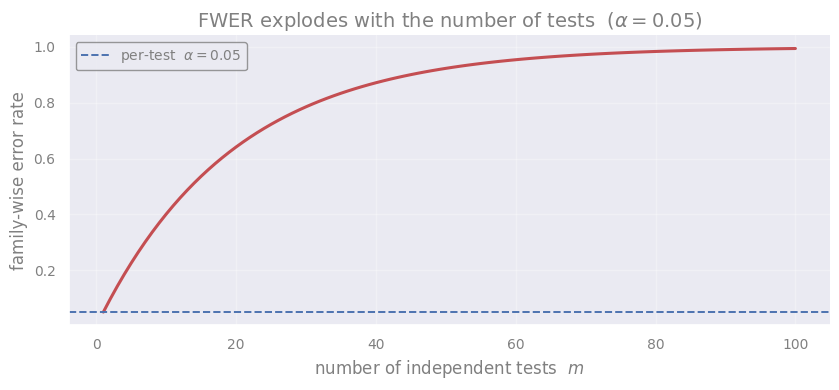

In [205]:
# ── FWER as a function of the number of tests ─────────────────────────────
alpha = 0.05
m_grid = np.arange(1, 101)
fwer = 1 - (1 - alpha) ** m_grid

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(m_grid, fwer, color="C3", lw=2.2)
ax.axhline(alpha, color="C0", ls="--", lw=1.4, label=fr"per-test  $\alpha = {alpha}$")
ax.set_xlabel(r"number of independent tests  $m$")
ax.set_ylabel("family-wise error rate")
ax.set_title(r"FWER explodes with the number of tests  ($\alpha = 0.05$)")
ax.legend()
plt.show()

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

Two standard remedies to keep multiple testing under control:

- **Bonferroni correction.**

  Declare a test significant only if its p-value is below $\alpha / m$ (instead of $\alpha$).

  $\rightarrow$ Controls the **FWER** at level $\alpha$.

- **Benjamini–Hochberg (BH) procedure for the False Discovery Rate (FDR).**

  Sort the $m$ p-values in increasing order, $p_{(1)} \leq \dots \leq p_{(m)}$. Find the largest $k$ such that

  $$ p_{(k)} \;\leq\; \frac{k}{m}\,\alpha \tag{15}$$

  and reject all hypotheses whose p-value is $\leq p_{(k)}$.

  $\rightarrow$ Controls **false discoveries among rejections** at level $\alpha$.

</div>


In [33]:
#EOF